In [1]:
import os
os.chdir('..')

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.io
from scipy.signal import resample_poly

from src.data.cwru_data import cwru_load_data

In [3]:
b_path = r"D:\Capstone\dataset\raw\CWRU\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat"
b_signal = scipy.io.loadmat(b_path)['X118_DE_time'].squeeze()

ir_path = r"D:\Capstone\dataset\raw\CWRU\12k_Drive_End_Bearing_Fault_Data\IR\007\105_0.mat"
ir_signal = scipy.io.loadmat(ir_path)['X105_DE_time'].squeeze()

or_path = r"D:\Capstone\dataset\raw\CWRU\12k_Drive_End_Bearing_Fault_Data\OR\007\@6\130@6_0.mat"
or_signal = scipy.io.loadmat(or_path)['X130_DE_time'].squeeze()

n_path = r"D:\Capstone\dataset\raw\CWRU\Normal\100_Normal_3.mat"
n_signal = scipy.io.loadmat(n_path)['X100_DE_time'].squeeze()
n_signal = resample_poly(n_signal, 1, 4)

faults = [or_signal, ir_signal, b_signal, n_signal]
labels = ["Outer Race", "Inner Race", "Ball", "Normal"]

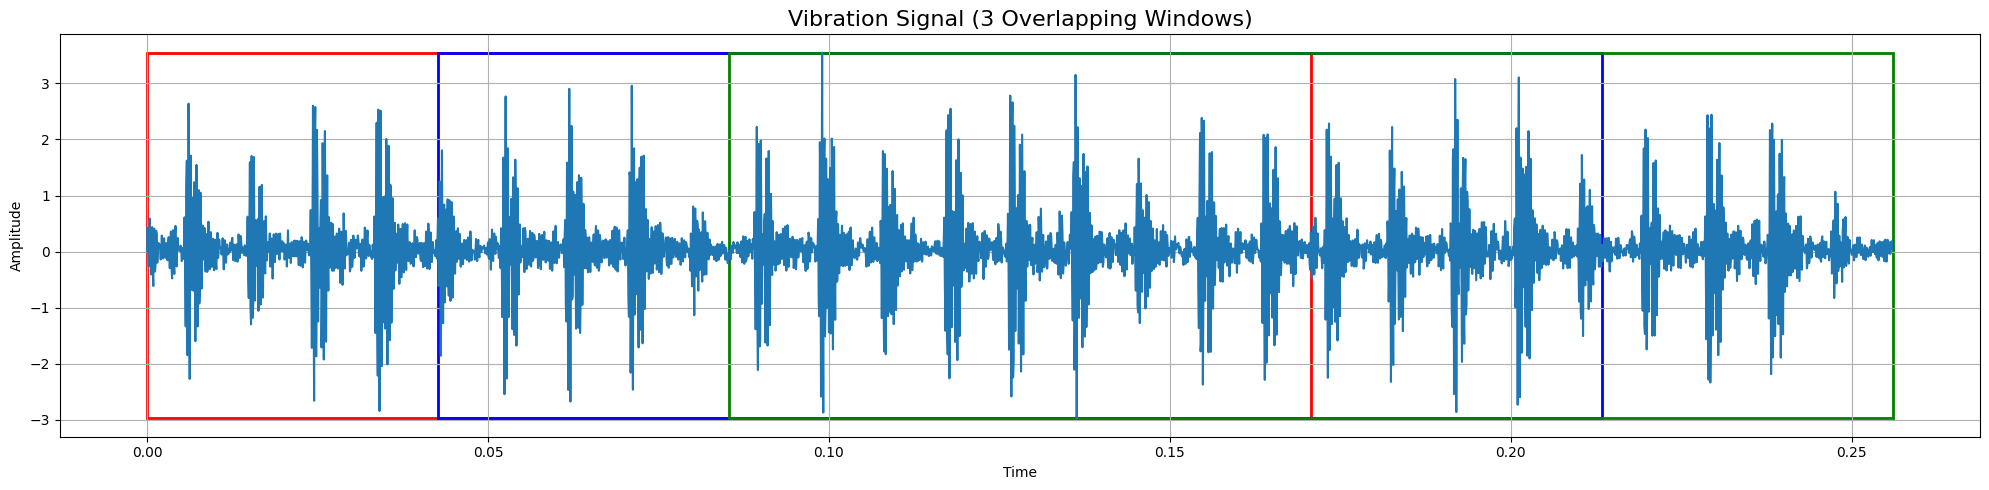

In [37]:
win_size = 2048
step = 512

x = 3072
signal = or_signal[:x]

fs = 12000
t = np.arange(len(signal)) / fs

fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(t, signal)

intervals = [
    (0, 2048, 'red'),
    (512, 2560, 'blue'),
    (1024, 3072, 'green')
]

y_min, y_max = signal.min(), signal.max()
height = y_max - y_min

for start, end, color in intervals:
    start_t = start / fs
    width_t = (end - start) / fs
    
    rect = patches.Rectangle(
        (start_t, y_min),
        width_t,
        height,
        linewidth=2,
        edgecolor=color,
        facecolor='none'
    )
    ax.add_patch(rect)

ax.set_xlabel("Time")
ax.set_ylabel("Amplitude")
ax.set_title("Vibration Signal (3 Overlapping Windows)", fontsize=16)
ax.grid(True)

plt.tight_layout()
plt.show()

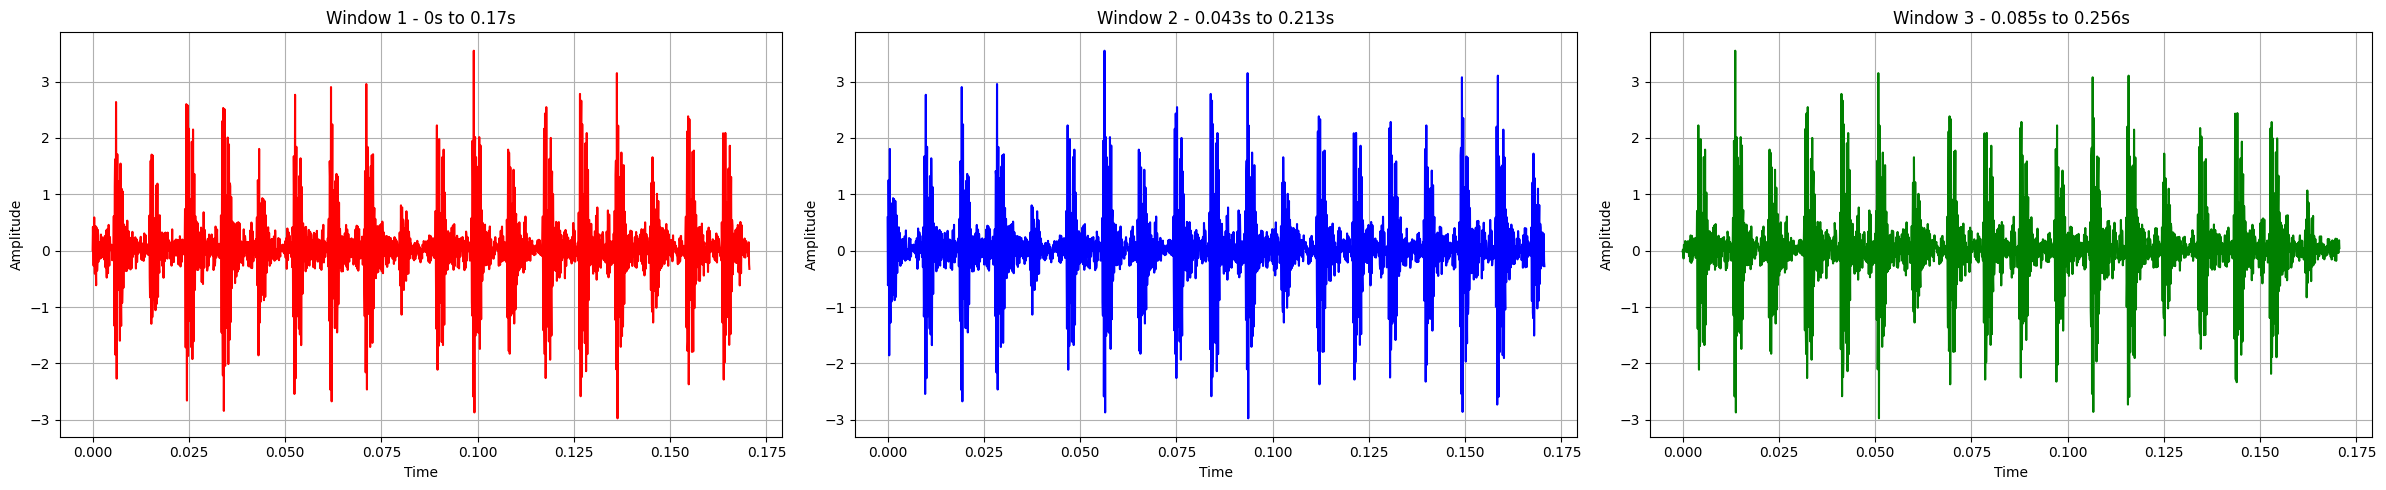

In [33]:
fig2, axes = plt.subplots(1, 3, figsize=(24, 5))

titles = [
    "Window 1 - 0s to 0.17s",
    "Window 2 - 0.043s to 0.213s",
    "Window 3 - 0.085s to 0.256s"
]

for i, (start, end, color) in enumerate(intervals):
    window_signal = signal[start:end]
    window_t = np.arange(len(window_signal)) / fs
    
    axes[i].plot(window_t, window_signal, color=color)
    axes[i].set_title(titles[i], fontsize=12)
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(True)

plt.tight_layout()
plt.show()